# Drag Optimization with a Discretized Sine-Wave Lid Velocity

This notebook samples a time-dependent lid velocity from `sin(t)`, treats those samples as the control vector `a`, and optimizes `a` to reduce drag along the cavity lid.

## 0 · Notebook Loader

In [ ]:
#reads notebook cells from .ipynb file
#returns dictionary of variables and functions

import json
from pathlib import Path

def run_notebook_cells(path, stop_on=None):
    candidate = Path(path)
    if not candidate.exists():
        candidate = Path("jax") / path

    with open(candidate) as f:
        nb = json.load(f)

    ns = {}
    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue

        src = "".join(cell["source"])
        src = "\n".join(
            line for line in src.splitlines()
            if not line.strip().startswith("%")
        )

        if stop_on and stop_on in src:
            print(f"  Stopped before cell {i} (trigger: '{stop_on}')")
            break

        try:
            exec(src, ns)
        except Exception as e:
            print(f"  Cell {i} skipped - {type(e).__name__}: {e}")

    return ns


## 1 · Import from the JAX Solver Notebook

In [ ]:
#loads cavity_flow_jax.ipynb and stops at line with u_sol, v_sol, p_sol = cavity_flow
print("Loading cavity_flow_jax.ipynb ...")
jax_ns = run_notebook_cells(
    "cavity_flow_jax.ipynb",
    stop_on="u_sol, v_sol, p_sol = cavity_flow",
)

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

build_up_b = jax_ns["build_up_b"]
pressure_poisson = jax_ns["pressure_poisson"]

nx = jax_ns["nx"]
ny = jax_ns["ny"]
nt = jax_ns["nt"]
dx = jax_ns["dx"]
dy = jax_ns["dy"]
rho = jax_ns["rho"]
nu = jax_ns["nu"]
dt = jax_ns["dt"]
x = jax_ns["x"]
y = jax_ns["y"]
X = jax_ns["X"]
Y = jax_ns["Y"]

print(f"Imported grid: nx={nx}, ny={ny}, nt={nt}")
print(f"Physics: rho={rho}, nu={nu}, dt={dt}, dx={dx}, dy={dy}")

#same physics as before, same nt, nx,ny

Loading cavity_flow_jax.ipynb ...
  Stopped before cell 5 (trigger: 'u_sol, v_sol, p_sol = cavity_flow')
Imported grid: nx=41, ny=41, nt=1000
Physics: rho=1.0, nu=0.1, dt=0.001, dx=0.025, dy=0.025


## 2 · Scan-Based Simulator with Time-Dependent Lid Control

In [ ]:
#a_i is lid velocity at each timestep
def step_fn(carry, a_i):
    """Advance the cavity-flow state by one timestep using lid velocity a_i."""
#Unpack currenthorizontal velocoty, verticla velocity, and pressure  
    u, v, p = carry
#build RHS of pressure equation for current state
    b = build_up_b(jnp.zeros((nx, ny)), rho, dt, u, v, dx, dy)
#solve pressure poisson equation
    p = pressure_poisson(p, dx, dy, b)
#save old velocities before update
    un, vn = u, v
#update interior of horizontal velocity field
    u = u.at[1:-1, 1:-1].set(
        un[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
        - dt / (2 * rho * dx) * (p[2:, 1:-1] - p[0:-2, 1:-1])
        + nu * (
            dt / dx**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])
            + dt / dy**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2])
        )
    )
#update vertical velocity field
    v = v.at[1:-1, 1:-1].set(
        vn[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
        - dt / (2 * rho * dy) * (p[1:-1, 2:] - p[1:-1, 0:-2])
        + nu * (
            dt / dx**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
            + dt / dy**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
        )
    )
#set left,right,and bottom horiznotal velociteis to zero
#update top wall horitonztal velocity set to control val a_i 
    u = u.at[:, 0].set(0.0)
    u = u.at[0, :].set(0.0)
    u = u.at[-1, :].set(0.0)
    u = u.at[:, -1].set(a_i)
#vertical velocity on all walls set to zero
    v = v.at[:, 0].set(0.0)
    v = v.at[:, -1].set(0.0)
    v = v.at[0, :].set(0.0)
    v = v.at[-1, :].set(0.0)
#return updated state 
    return (u, v, p), None

#define full simulation using vector a
def run_sim(a):
    """Run the full simulation with one lid-velocity control per timestep."""
#inital velocties and pressure
    u0 = jnp.zeros((nx, ny))
    v0 = jnp.zeros((nx, ny))
    p0 = jnp.zeros((nx, ny))
#appleis step_fn repeatedly across all timesteps with each a_i
    (u_f, v_f, p_f), _ = jax.lax.scan(step_fn, (u0, v0, p0), a)
#return final flow state
    return u_f, v_f, p_f


print("step_fn and run_sim defined.")


step_fn and run_sim defined.


## 3 · Sample the Initial Sine-Wave Control

In [ ]:
#simulation time array
t = jnp.arange(nt) * dt
#total duration of simulation
total_time = nt * dt
#time rescale so a full sin wave fits into whole simulation window
phase = 2.0 * jnp.pi * t / total_time

a0 = jnp.sin(phase) #sample sin wave at each time step. a0 gets updated

print(f"a0 shape: {a0.shape}")
print(f"a0 min/max: {float(jnp.min(a0)):.6f}, {float(jnp.max(a0)):.6f}") #sin goes from -1 to 1
print(f"Initial control completes one sine-wave cycle over T={total_time:.3f} seconds")


a0 shape: (1000,)
a0 min/max: -1.000000, 1.000000
Initial control completes one sine-wave cycle over T=1.000 seconds


## 4 · Drag Loss and Gradient

In [ ]:
#helper for lid shear
#how quickly u changes in vertical direction right next to top wall

#sum of du/dy across top lid = drag
def top_wall_shear(u):
    #u at lid, u just below lid, dy is vertical grid spacing
    #approx of du/dy at top wall
    #u_top - u_one_cell_below /dy
#loss just adds shear across whole top wall
    return (u[:, -1] - u[:, -2]) / dy

#objective fn
def loss(a):
#run simulation with control a
    u_f, v_f, p_f = run_sim(a)
#compute top wall shear from final horizontal velocity
    du_dy_top = top_wall_shear(u_f)
#define loss as signed sum of top-wall shear / drag
#negative loss is not a coding error here. It is a consequence of using the signed sum of du/dy as the objective.
    return jnp.sum(du_dy_top)

#compiled JAX fn returning both loss and dL/da
grad_fn = jax.jit(jax.value_and_grad(loss))

print("Loss and gradient function compiled.")
print("The first call will include JAX compilation time.")


Loss and gradient function compiled.
The first call will include JAX compilation time.


## 5 · Quick Validation Pass

In [ ]:
#validaitons

u_test, v_test, p_test = run_sim(a0)
loss0, grad0 = grad_fn(a0)

print(f"u_test shape: {u_test.shape}, finite={bool(jnp.isfinite(u_test).all())}")
print(f"v_test shape: {v_test.shape}, finite={bool(jnp.isfinite(v_test).all())}")
print(f"p_test shape: {p_test.shape}, finite={bool(jnp.isfinite(p_test).all())}")
print(f"Initial loss: {float(loss0):.6f}")
print(f"grad shape: {grad0.shape}")
print(f"grad L2 norm: {float(jnp.linalg.norm(grad0)):.6e}")
print(f"nonzero gradient: {bool(jnp.any(jnp.abs(grad0) > 0))}")


u_test shape: (41, 41), finite=True
v_test shape: (41, 41), finite=True
p_test shape: (41, 41), finite=True
Initial loss: 103.199264
grad shape: (1000,)
grad L2 norm: 1.674415e+03
nonzero gradient: True


## 6 · Gradient-Based Optimization

In [ ]:
#start optimiation from sin wave
a = a0
lr = 1e-3 #learnign rate and number of optimization iteraitons
n_iters = 50

loss_history = []
grad_norm_history = []

#loop 50 times
for i in range(n_iters):
    val, grads = grad_fn(a) #compute loss and dL/da
    a = a - lr * grads #manual gradient descent

#update histories
    loss_history.append(float(val))
    grad_norm_history.append(float(jnp.linalg.norm(grads)))

    if i % 10 == 0:
        print(f"iter {i:3d}  loss={float(val):.6f}  |grad|={float(jnp.linalg.norm(grads)):.4e}")

print("Optimization complete.")


iter   0  loss=103.199264  |grad|=1.6744e+03
iter  10  loss=-27932.759820  |grad|=1.6744e+03
iter  20  loss=-55967.328719  |grad|=1.6743e+03
iter  30  loss=-84000.587937  |grad|=1.6743e+03
iter  40  loss=-112032.612451  |grad|=1.6743e+03
Optimization complete.


## 7 · Results

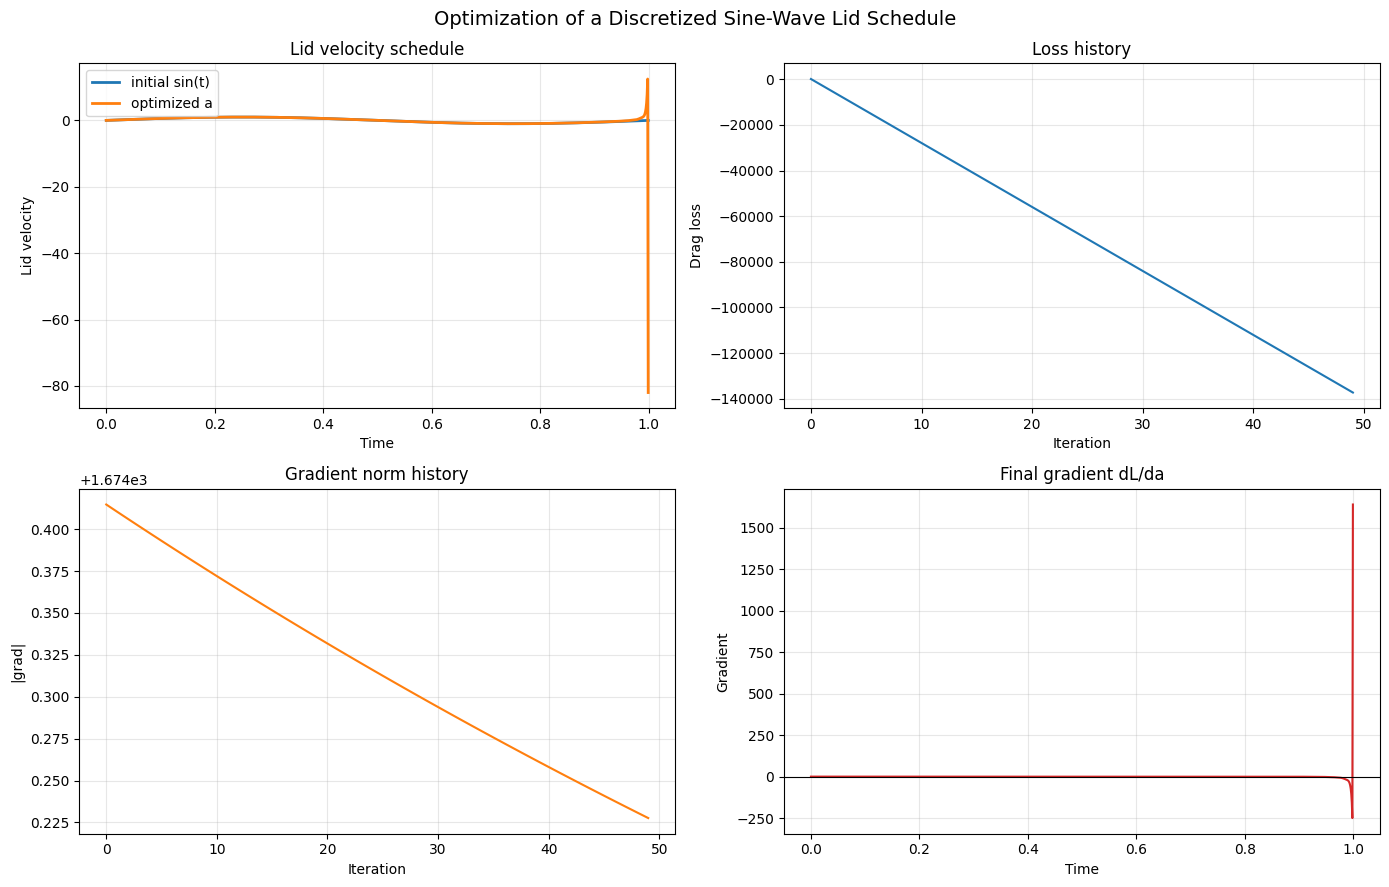

Initial loss: 103.199264
Final loss:   -140063.472063


In [27]:
final_loss, final_grads = grad_fn(a)
u_opt, v_opt, p_opt = run_sim(a)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Optimization of a Discretized Sine-Wave Lid Schedule", fontsize=14)

axes[0, 0].plot(np.array(t), np.array(a0), label="initial sin(t)", linewidth=2)
axes[0, 0].plot(np.array(t), np.array(a), label="optimized a", linewidth=2)
axes[0, 0].set_title("Lid velocity schedule")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Lid velocity")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(loss_history, color="tab:blue")
axes[0, 1].set_title("Loss history")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Drag loss")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(grad_norm_history, color="tab:orange")
axes[1, 0].set_title("Gradient norm history")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("|grad|")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(np.array(t), np.array(final_grads), color="tab:red")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_title("Final gradient dL/da")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Gradient")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {float(final_loss):.6f}")


## 9 · Final Flow Visualization

## 8 · Initial vs Final Lid Velocity

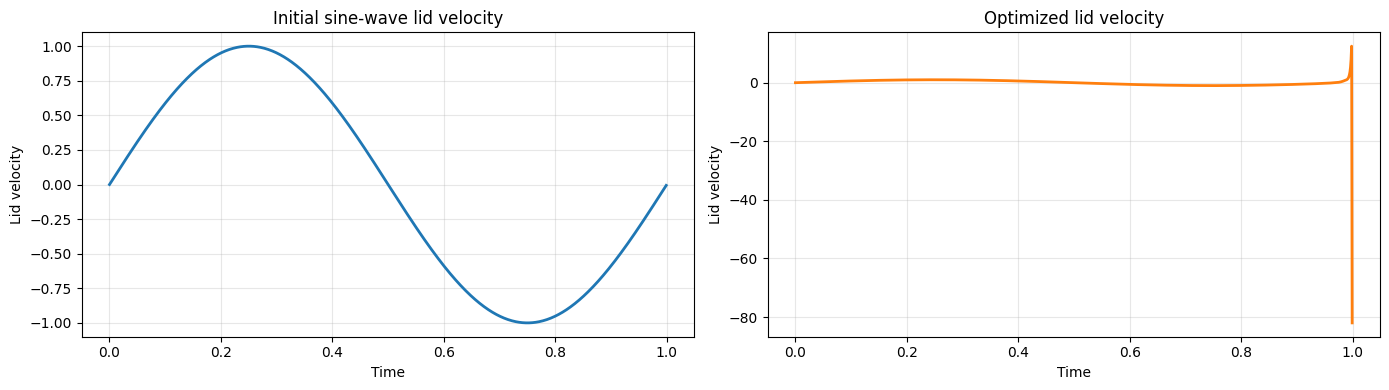

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(np.array(t), np.array(a0), label="Initial lid velocity", linewidth=2)
axes[0].set_title("Initial sine-wave lid velocity")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Lid velocity")
axes[0].grid(alpha=0.3)

axes[1].plot(np.array(t), np.array(a), label="Optimized lid velocity", linewidth=2, color="tab:orange")
axes[1].set_title("Optimized lid velocity")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Lid velocity")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


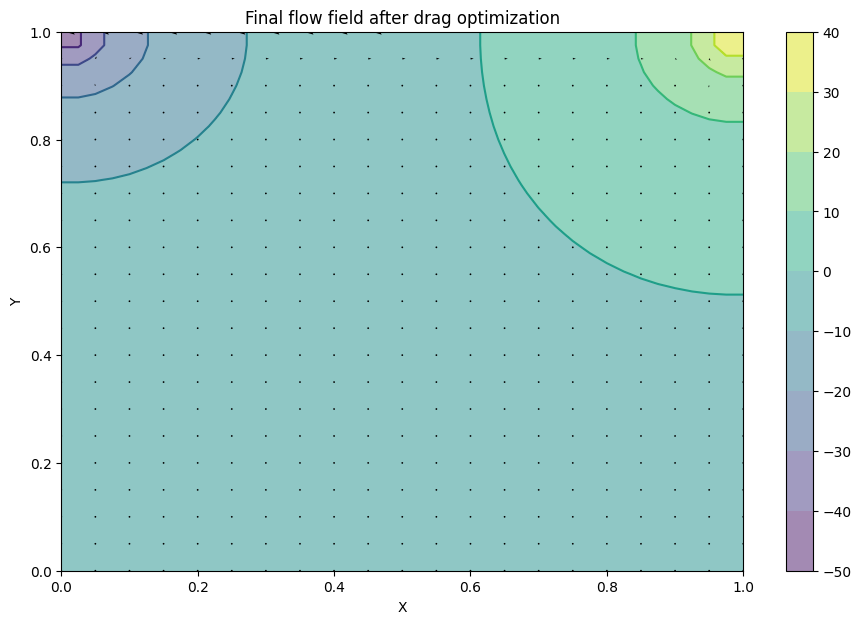

In [29]:
fig = plt.figure(figsize=(11, 7), dpi=100)
plt.contourf(np.array(X), np.array(Y), np.array(p_opt), alpha=0.5, cmap="viridis")
plt.colorbar()
plt.contour(np.array(X), np.array(Y), np.array(p_opt), cmap="viridis")
plt.quiver(
    np.array(X)[::2, ::2],
    np.array(Y)[::2, ::2],
    np.array(u_opt)[::2, ::2],
    np.array(v_opt)[::2, ::2],
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Final flow field after drag optimization")
plt.show()
